In [13]:
import pandas as pd
from pyfaidx import Fasta
from Bio import SeqIO
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from Bio.Seq import Seq

In [14]:
m_location_df = pd.read_csv("/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/RNAlocate/mRNA_location_resources.csv")
m_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score
0,FOXM1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.815591
1,AIMP2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006
2,LASP1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006
3,FLOT2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006
4,ACTG2,mRNA,Homo sapiens,"human CRC cell lines (SW837, LOVO)",Cytoplasm,0.795006
...,...,...,...,...,...,...
239558,GNAI1,mRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359
239559,RTF2,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359
239560,PSMD3,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359
239561,PNPLA6,mRNA,Homo sapiens,HeLa-S3 cells|K562 cells,Nucleus,0.396359


In [15]:
# 1. 提取 FASTA 文件中的序列并存入字典 (仅保留遇到的第一个 RNA Symbol对应的序列)
fasta_file = "/lulabdata3/huangkeyun/zhangys/RNA_locator/resources/ensenble/Homo_sapiens.GRCh38.cdna.all.fa"
fasta_dict = {}

with open(fasta_file, "r") as f:
    current_symbol = None
    current_seq = []
    
    for line in f:
        line = line.strip()
        if line.startswith(">"):
            # 保存上一个序列
            if current_symbol and current_symbol not in fasta_dict:
                fasta_dict[current_symbol] = "".join(current_seq)
            
            # 以空格分割，遍历寻找 'gene_symbol:' 字段，这样更健壮
            current_symbol = None
            parts = line.split(" ")
            for part in parts:
                if part.startswith("gene_symbol:"):
                    current_symbol = part.split("gene_symbol:")[1]
                    break
            
            current_seq = []
        else:
            if current_symbol is not None:
                current_seq.append(line)
            
    # 保存最后一个序列
    if current_symbol and current_symbol not in fasta_dict:
        fasta_dict[current_symbol] = "".join(current_seq)

# 2. 将序列映射到 m_location_df 的 Sequence 列
# 假设你的 DataFrame 中包含 'RNA Symbol' 这一列，如果不叫这个名字请根据实际情况替换列名
m_location_df['Sequence'] = m_location_df['RNA Symbol'].map(fasta_dict)

m_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score,Sequence
0,FOXM1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.815591,AACGCTCCGCCGGCGCCAATTTCAAACAGCGGAACAAACTGAAAGC...
1,AIMP2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,ACGCCCGCAGCAGGGTCAGAAGGGAGGTGGCCGGTCTCCGTCGTGA...
2,LASP1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,GCAGTCAGCCTGAGAGCGCTGAGGCGCCAGCACCGCGGGCCCCGCC...
3,FLOT2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,GGGCGCGGCCGGCGCTGCAGACCCGCTGCTGTTGTCCGGGTCTGTG...
4,ACTG2,mRNA,Homo sapiens,"human CRC cell lines (SW837, LOVO)",Cytoplasm,0.795006,GTTAGGTGTGCCTCAACCCTGAAGCAGGTCCCTCAGTCTGCAGATA...
...,...,...,...,...,...,...,...
239558,GNAI1,mRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,GGGAGGCTCGGGCCGCACAGGTGCCCATGGAGGGAGTGAGAGGCTC...
239559,RTF2,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359,ACGACCAGCGTGCTGCGTCACGGCGGTGCGCCGGAAGTGGCTGCGG...
239560,PSMD3,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359,AGAAGGCCCAGCGCCGGGAAGGGGTTTGCAGCTGCTCCGTCATCGT...
239561,PNPLA6,mRNA,Homo sapiens,HeLa-S3 cells|K562 cells,Nucleus,0.396359,TTTTTAGCGGGAGGAGCAGTCCTTGCGTTAAGCGGTGTGAGGCCCT...


In [16]:
# 3. 去除 Sequence 为空或包含 'N' 的行
# 去除空值 (NaN)
m_location_df = m_location_df.dropna(subset=['Sequence'])
# 过滤掉 Sequence 包含大写 'N' 或小写 'n' 的行，并重置索引
m_location_df = m_location_df[~m_location_df['Sequence'].str.contains('N|n')].reset_index(drop=True)

m_location_df

,RNA Symbol,RNA Category,Species,Tissue/Cell Line,Localization,Score,Sequence
0,FOXM1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.815591,AACGCTCCGCCGGCGCCAATTTCAAACAGCGGAACAAACTGAAAGC...
1,AIMP2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,ACGCCCGCAGCAGGGTCAGAAGGGAGGTGGCCGGTCTCCGTCGTGA...
2,LASP1,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,GCAGTCAGCCTGAGAGCGCTGAGGCGCCAGCACCGCGGGCCCCGCC...
3,FLOT2,mRNA,Homo sapiens,Hepatocellular carcinoma Huh7 cell,Cytoplasm,0.795006,GGGCGCGGCCGGCGCTGCAGACCCGCTGCTGTTGTCCGGGTCTGTG...
4,ACTG2,mRNA,Homo sapiens,"human CRC cell lines (SW837, LOVO)",Cytoplasm,0.795006,GTTAGGTGTGCCTCAACCCTGAAGCAGGTCCCTCAGTCTGCAGATA...
...,...,...,...,...,...,...,...
238209,GNAI1,mRNA,Homo sapiens,HeLa-S3 cells,Nucleus,0.396359,GGGAGGCTCGGGCCGCACAGGTGCCCATGGAGGGAGTGAGAGGCTC...
238210,RTF2,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359,ACGACCAGCGTGCTGCGTCACGGCGGTGCGCCGGAAGTGGCTGCGG...
238211,PSMD3,mRNA,Homo sapiens,HCC cell line (HepG2)|K562 cells,Nucleus,0.396359,AGAAGGCCCAGCGCCGGGAAGGGGTTTGCAGCTGCTCCGTCATCGT...
238212,PNPLA6,mRNA,Homo sapiens,HeLa-S3 cells|K562 cells,Nucleus,0.396359,TTTTTAGCGGGAGGAGCAGTCCTTGCGTTAAGCGGTGTGAGGCCCT...


m_location_df 清洗完成：删除了 4599 条过长序列，剩余 233615 条。

--- m_location_df 长度统计 ---
最短序列长度: 58
最长序列长度: 11230
平均序列长度: 2997.17


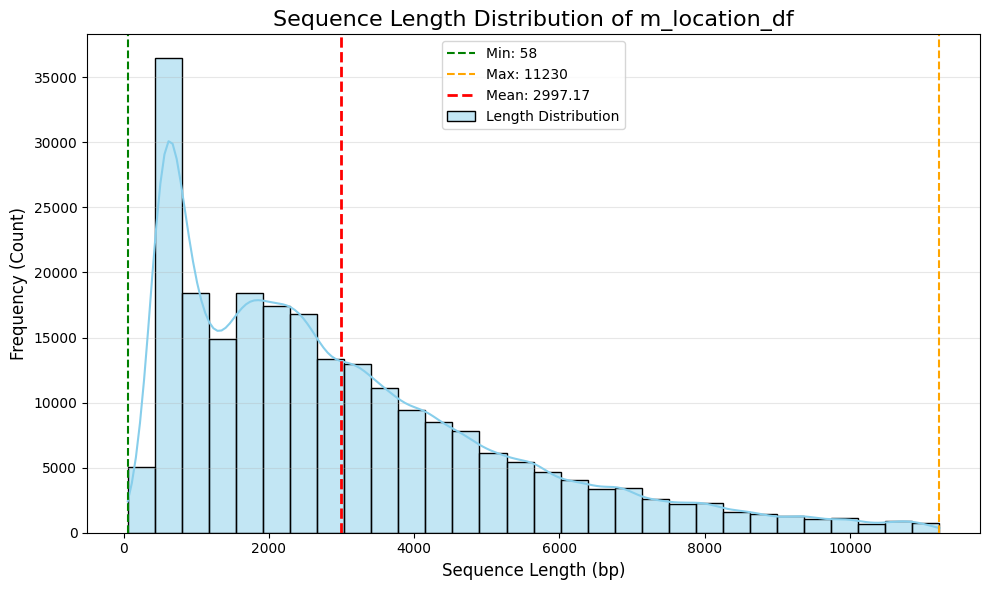

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 长度清晰
m_location_df['Sequence_Length'] = m_location_df['Sequence'].str.len()
original_m_count = len(m_location_df)

# 执行长度过滤（保留 <= 11238 bp 的行，具体阈值可根据需要调整）
m_location_df = m_location_df[m_location_df['Sequence_Length'] <= 11238].copy()

# 统计并打印结果
deleted_m = original_m_count - len(m_location_df)
print(f"m_location_df 清洗完成：删除了 {deleted_m} 条过长序列，剩余 {len(m_location_df)} 条。\n")

# 计算序列长度
m_location_df['Sequence_Length'] = m_location_df['Sequence'].str.len()

# 1. 基础统计量计算
max_length = m_location_df['Sequence_Length'].max()
min_length = m_location_df['Sequence_Length'].min()
average_length = m_location_df['Sequence_Length'].mean()

print(f"--- m_location_df 长度统计 ---")
print(f"最短序列长度: {min_length}")
print(f"最长序列长度: {max_length}")
print(f"平均序列长度: {average_length:.2f}")

# 2. 设置分箱区间并打印分布详情
bins = np.histogram_bin_edges(m_location_df['Sequence_Length'], bins=30)
bin_counts, bin_edges = np.histogram(m_location_df['Sequence_Length'], bins=bins)


# 3. 绘制分布图
plt.figure(figsize=(10, 6))
sns.histplot(m_location_df['Sequence_Length'], bins=bins, kde=True, color='skyblue', label='Length Distribution')

# 4. 添加最小值、最大值和平均值的垂直标注线
plt.axvline(min_length, color='green', linestyle='--', linewidth=1.5, label=f'Min: {min_length}')
plt.axvline(max_length, color='orange', linestyle='--', linewidth=1.5, label=f'Max: {max_length}')
plt.axvline(average_length, color='red', linestyle='--', linewidth=2, label=f'Mean: {average_length:.2f}')

# 5. 图形细节美化
plt.title('Sequence Length Distribution of m_location_df', fontsize=16)
plt.xlabel('Sequence Length (bp)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 6. 展示图形
plt.show()

In [18]:
m_location_df['Localization'].value_counts()

Localization
Extracellular exosome    118808
Nucleus                   51457
Cytosol                   50852
Cytoplasm                 10452
Extracellular vesicle      2010
Mitochondrion                36
Name: count, dtype: int64

In [19]:
# 根据 Localization 列的内容生成 tag 列
m_location_df['tag'] = m_location_df['Localization'].isin(['Extracellular exosome', 'Extracellular vesicle']).astype(int)

# 查看 tag 列的结果分布
m_location_df['tag'].value_counts()

tag
1    120818
0    112797
Name: count, dtype: int64

In [20]:
print("平衡前的标签分布:")
print(m_location_df['tag'].value_counts())

# 获取少数类的样本数量
min_count = m_location_df['tag'].value_counts().min()

# 按 tag 分组，并随机抽取与少数类相同数量的样本 (设置 random_state 保证结果可复现)
m_location_df = m_location_df.groupby('tag').sample(n=min_count, random_state=42).reset_index(drop=True)

# 查看平衡后的结果分布
print("\n平衡后的标签分布:")
print(m_location_df['tag'].value_counts())

平衡前的标签分布:
tag
1    120818
0    112797
Name: count, dtype: int64

平衡后的标签分布:
tag
0    112797
1    112797
Name: count, dtype: int64


In [21]:
# 4. 将 DataFrame 保存为 FASTA 文件
output_fasta = "./linearDataSet/mRNA_balanced_dataset.fa"

with open(output_fasta, "w") as f:
    for index, row in m_location_df.iterrows():
        # 拼接 RNA Symbol 和 tag 作为标题
        header = f">{row['RNA Symbol']}_{row['tag']}"
        sequence = row['Sequence']
        f.write(f"{header}\n{sequence}\n")